# **Car Price Prediction using RANDOM FOREST**


## About the Project
In this project, we work with a car prices dataset containing information about cars such as fueltype, aspiration, doornumber, carbody, drivewheel, enginetype, cylindernumber, horsepower, peakrpm, citympg, highwaympg, and the target `price`. Our objective is to build a regression model that predicts the car price using the Random Forest algorithm.


## Goal
To use the Random Forest regression technique to build a model that predicts the price of a car given its features.


## Dataset Details
- **car_ID**: Unique ID for each car (dropped before modeling)
- **symboling**: Car insurance risk rating
- **fueltype**: fuel type (gas/diesel)
- **aspiration**: aspiration (std/turbo)
- **doornumber**: number of doors
- **carbody**: body style
- **drivewheel**: drive wheel type
- **enginelocation**: front/rear
- **wheelbase, length, width, height**: dimensions
- **curbweight**: vehicle weight
- **enginetype, cylindernumber, enginesize**: engine details
- **fuelsystem**: fuel system
- **horsepower, peakrpm, citympg, highwaympg**: performance specs
- **price**: target variable (continuous)


## Methodologies
1. Data Cleaning and Preprocessing: handle missing values and encode categorical variables.
2. Exploratory Data Analysis (EDA): inspect distributions and relationships.
3. Model Building: train a Random Forest Regressor.
4. Model Evaluation: evaluate using RMSE, MAE, and R²; visualize predictions and residuals.


In [1]:
# Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import os


In [6]:
df = pd.read_csv("/content/dataset.csv")
df.head()

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


In [7]:
# Drop car_ID

if 'car_ID' in df.columns:
    df = df.drop(['car_ID'], axis=1)

print("Dataset shape:", df.shape)
df.head()


Dataset shape: (205, 25)


,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,carlength,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,168.8,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,168.8,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,171.2,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,176.6,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,176.6,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


In [8]:
# Quick EDA
print("Columns:", list(df.columns))
print("\nMissing values per column:")
print(df.isnull().sum())

# Basic statistics for numeric columns
print("\nNumeric summary:")
display(df.select_dtypes(include=[np.number]).describe().T)


Columns: ['symboling', 'CarName', 'fueltype', 'aspiration', 'doornumber', 'carbody', 'drivewheel', 'enginelocation', 'wheelbase', 'carlength', 'carwidth', 'carheight', 'curbweight', 'enginetype', 'cylindernumber', 'enginesize', 'fuelsystem', 'boreratio', 'stroke', 'compressionratio', 'horsepower', 'peakrpm', 'citympg', 'highwaympg', 'price']

Missing values per column:
symboling           0
CarName             0
fueltype            0
aspiration          0
doornumber          0
carbody             0
drivewheel          0
enginelocation      0
wheelbase           0
carlength           0
carwidth            0
carheight           0
curbweight          0
enginetype          0
cylindernumber      0
enginesize          0
fuelsystem          0
boreratio           0
stroke              0
compressionratio    0
horsepower          0
peakrpm             0
citympg             0
highwaympg          0
price               0
dtype: int64

Numeric summary:


,count,mean,std,min,25%,50%,75%,max
symboling,205.0,0.834146,1.245307,-2.00,0.00,1.00,2.00,3.00
wheelbase,205.0,98.756585,6.021776,86.60,94.50,97.00,102.40,120.90
carlength,205.0,174.049268,12.337289,141.10,166.30,173.20,183.10,208.10
carwidth,205.0,65.907805,2.145204,60.30,64.10,65.50,66.90,72.30
carheight,205.0,53.724878,2.443522,47.80,52.00,54.10,55.50,59.80
curbweight,205.0,2555.565854,520.680204,1488.00,2145.00,2414.00,2935.00,4066.00
enginesize,205.0,126.907317,41.642693,61.00,97.00,120.00,141.00,326.00
boreratio,205.0,3.329756,0.270844,2.54,3.15,3.31,3.58,3.94
stroke,205.0,3.255415,0.313597,2.07,3.11,3.29,3.41,4.17
compressionratio,205.0,10.142537,3.972040,7.00,8.60,9.00,9.40,23.00


In [9]:
# Separate features and target
target = 'price'
X = df.drop(columns=[target])
y = df[target]

In [10]:
# Identify numeric and categorical columns
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()

print("Numeric columns:", num_cols)
print("Categorical columns:", cat_cols)


Numeric columns: ['symboling', 'wheelbase', 'carlength', 'carwidth', 'carheight', 'curbweight', 'enginesize', 'boreratio', 'stroke', 'compressionratio', 'horsepower', 'peakrpm', 'citympg', 'highwaympg']
Categorical columns: ['CarName', 'fueltype', 'aspiration', 'doornumber', 'carbody', 'drivewheel', 'enginelocation', 'enginetype', 'cylindernumber', 'fuelsystem']


In [11]:
# Build preprocessing pipeline
numeric_transformer = Pipeline(steps=[('scaler', StandardScaler())])
categorical_transformer = Pipeline(steps=[('onehot', OneHotEncoder(handle_unknown='ignore'))])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, num_cols),
    ('cat', categorical_transformer, cat_cols)
])

In [14]:
# Create full pipeline with RandomForestRegressor
model = Pipeline(steps=[('preprocessor', preprocessor),
                        ('regressor', RandomForestRegressor(n_estimators=100, random_state=42))])

In [15]:

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Train shape:", X_train.shape, "Test shape:", X_test.shape)


Train shape: (164, 24) Test shape: (41, 24)


In [17]:
# Train the model
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluation metrics
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"R²: {r2:.3f}")

RMSE: 1877.26
MAE: 1323.84
R²: 0.955


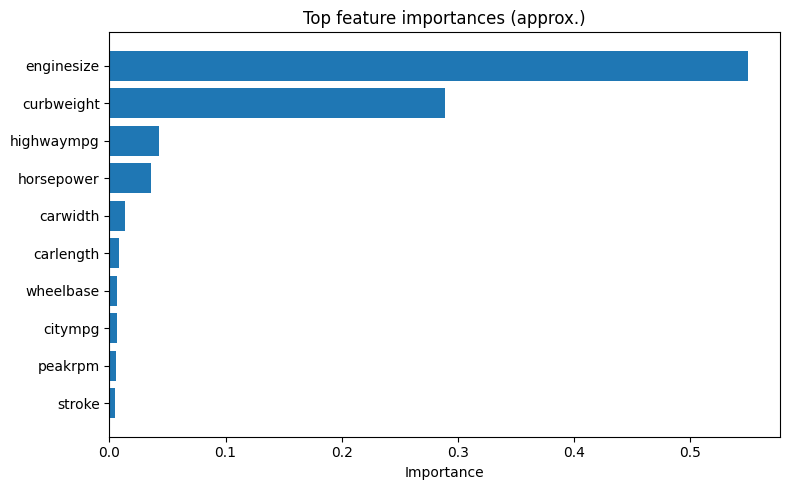

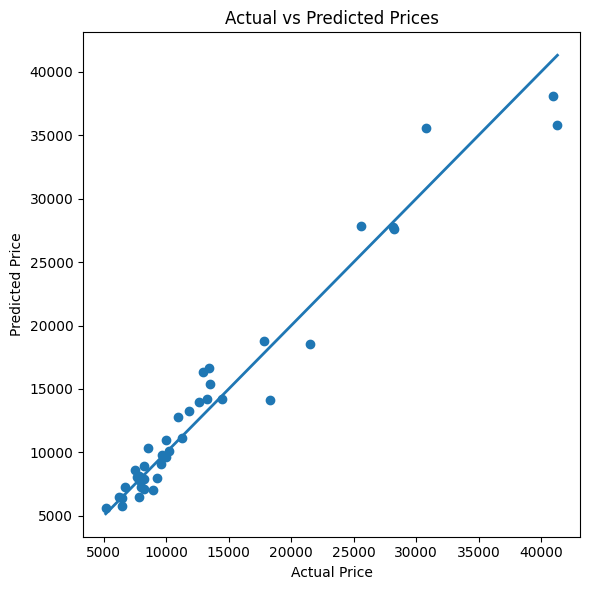

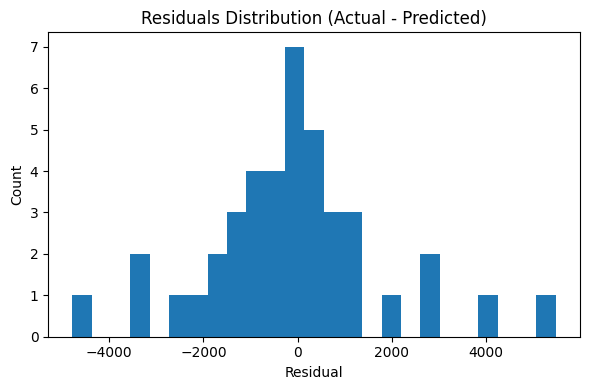

In [18]:

# Visualizations

# 1) Feature importance (approximate): extract feature names after preprocessing
# Get feature names from onehot encoder and numeric columns
pre = model.named_steps['preprocessor']
# numeric names
num_features = num_cols
# onehot feature names (if any)
oh = pre.named_transformers_['cat'].named_steps['onehot']
try:
    oh_features = oh.get_feature_names_out(cat_cols).tolist()
except Exception:
    # fallback name generation
    oh_features = []
feature_names = num_features + oh_features

# Extract feature importances from the Random Forest (regressor)
importances = model.named_steps['regressor'].feature_importances_
# Safety check
if len(importances) != len(feature_names):
    # If lengths mismatch, compute importances by grouping numeric vs categorical aggregate importance
    print("Warning: feature names length mismatch. Showing top numeric features instead.")
    feat_imp = list(zip(num_features, importances[:len(num_features)]))
else:
    feat_imp = list(zip(feature_names, importances))

# Sort and display top 10 features
feat_imp_sorted = sorted(feat_imp, key=lambda x: x[1], reverse=True)[:10]
feat_names_top = [f[0] for f in feat_imp_sorted]
feat_vals_top = [f[1] for f in feat_imp_sorted]

# Bar plot of top features
plt.figure(figsize=(8,5))
plt.barh(feat_names_top[::-1], feat_vals_top[::-1])
plt.title("Top feature importances (approx.)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

# 2) Actual vs Predicted scatter
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], linewidth=2)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices")
plt.tight_layout()
plt.show()

# 3) Residuals histogram
residuals = y_test - y_pred
plt.figure(figsize=(6,4))
plt.hist(residuals, bins=25)
plt.title("Residuals Distribution (Actual - Predicted)")
plt.xlabel("Residual")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


In [19]:

# Example: Predict price for the first 5 test samples (show features and predicted price)
X_test_reset = X_test.reset_index(drop=True)
sample_X = X_test_reset.head(5)
sample_preds = model.predict(sample_X)
sample_display = sample_X.copy()
sample_display['predicted_price'] = np.round(sample_preds, 2)
sample_display.head()


,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,carlength,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,predicted_price
0,0,bmw x4,gas,std,four,sedan,rwd,front,103.5,189.0,...,209,mpfi,3.62,3.39,8.00,182,5400,16,22,35544.39
1,0,audi 5000s (diesel),gas,turbo,two,hatchback,4wd,front,99.5,178.2,...,131,mpfi,3.13,3.40,7.00,160,5500,16,22,18751.91
2,0,nissan nv200,gas,std,four,sedan,fwd,front,97.2,173.4,...,120,2bbl,3.33,3.47,8.50,97,5200,27,34,9105.29
3,3,saab 99e,gas,std,two,hatchback,fwd,front,99.1,186.6,...,121,mpfi,3.54,3.07,9.31,110,5250,21,28,13263.79
4,-1,buick century luxus (sw),diesel,turbo,four,wagon,rwd,front,110.0,190.9,...,183,idi,3.58,3.64,21.50,123,4350,22,25,27649.98


## Model Evaluation
The Random Forest regressor was evaluated using the following metrics:

- **RMSE (Root Mean Squared Error)**: measures the average magnitude of the errors.
- **MAE (Mean Absolute Error)**: average absolute difference between actual and predicted values.
- **R² (Coefficient of Determination)**: proportion of variance explained by the model.

These metrics help us judge how well the regression model predicts continuous prices.

## Skills Developed
- Practical experience in data cleaning and preprocessing with pandas and NumPy.
- Proficiency in exploratory data analysis (EDA) using matplotlib.
- Understanding Random Forest regression and feature importance.
- Gaining insights into regression model evaluation through RMSE, MAE, and R².


## Task Type
This is a **regression** task because the target variable (`price`) is continuous (numerical) and the model predicts real-valued prices.

## Conclusion
The Random Forest regressor provides a robust baseline for predicting car prices. In this run:

- We trained a Random Forest model with default settings (100 trees).
- Evaluation metrics (RMSE, MAE, and R²) give an idea of prediction quality — lower RMSE/MAE and higher R² are better.
- Feature importance identifies which attributes most influence price predictions (e.g., enginesize, horsepower, curbweight, etc.).

Next steps to improve the model:
1. Perform hyperparameter tuning (GridSearchCV or RandomizedSearchCV).
2. Engineer additional features (e.g., age of car, power-to-weight ratio).
3. Use more data or external datasets for better generalization.
